In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy import stats

# ── Project Paths ──────────────────────────────────────────────────
DATA_DIR     = r"C:\Data Science\DS Projects\Health vs Wealth analysis"
CHART_DIR_H1 = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO\Hypothesis 1"
CHART_DIR_H2 = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO\Hypothesis 2"
CHART_DIR_H3 = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO\Hypothesis 3"

WHO_FILE     = os.path.join(DATA_DIR, "Life_Expectancy_Data_1_CSV.csv")
GDP_FILE     = os.path.join(DATA_DIR, "GDP per capita main CSV.csv")
POP_FILE     = os.path.join(DATA_DIR, "Population main CSV.csv")
SUICIDE_FILE = os.path.join(DATA_DIR, "suicide_rates_who.csv")

# ── Create folder structure ────────────────────────────────────────
os.makedirs(CHART_DIR_H1, exist_ok=True)
os.makedirs(CHART_DIR_H2, exist_ok=True)
os.makedirs(CHART_DIR_H3, exist_ok=True)

# ── Load Data ──────────────────────────────────────────────────────
who         = pd.read_csv(WHO_FILE)
gdp_wb      = pd.read_csv(GDP_FILE, skiprows=4)
pop_wb      = pd.read_csv(POP_FILE, skiprows=4)
suicide_raw = pd.read_csv(SUICIDE_FILE)

# ── Clean column names ─────────────────────────────────────────────
who.columns    = who.columns.str.strip()
gdp_wb.columns = gdp_wb.columns.str.strip()
pop_wb.columns = pop_wb.columns.str.strip()

# ── Reshape World Bank files from wide to long ─────────────────────
gdp_long = gdp_wb.melt(
    id_vars    = ['Country Name', 'Country Code'],
    value_vars = [str(y) for y in range(2000, 2016)],
    var_name   = 'Year',
    value_name = 'GDP_per_capita'
)
gdp_long['Year'] = gdp_long['Year'].astype(int)

pop_long = pop_wb.melt(
    id_vars    = ['Country Name', 'Country Code'],
    value_vars = [str(y) for y in range(2000, 2016)],
    var_name   = 'Year',
    value_name = 'Population'
)
pop_long['Year'] = pop_long['Year'].astype(int)

# ── Rename WHO countries to match World Bank naming ────────────────
who['Country'] = who['Country'].replace({
    'Bahamas'                                             : 'Bahamas, The',
    'Bolivia (Plurinational State of)'                    : 'Bolivia',
    'Congo'                                               : 'Congo, Rep.',
    'Democratic Republic of the Congo'                    : 'Congo, Dem. Rep.',
    "CÃ´te d'Ivoire"                                      : "Cote d'Ivoire",
    'Egypt'                                               : 'Egypt, Arab Rep.',
    'Gambia'                                              : 'Gambia, The',
    'Iran (Islamic Republic of)'                          : 'Iran, Islamic Rep.',
    'Kyrgyzstan'                                          : 'Kyrgyz Republic',
    "Lao People's Democratic Republic"                    : 'Lao PDR',
    'Micronesia (Federated States of)'                    : 'Micronesia, Fed. Sts.',
    'Republic of Korea'                                   : 'Korea, Rep.',
    'Republic of Moldova'                                 : 'Moldova',
    "Democratic People's Republic of Korea"               : "Korea, Dem. People's Rep.",
    'Slovakia'                                            : 'Slovak Republic',
    'Swaziland'                                           : 'Eswatini',
    'The former Yugoslav republic of Macedonia'           : 'North Macedonia',
    'Turkey'                                              : 'Turkiye',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United Republic of Tanzania'                         : 'Tanzania',
    'United States of America'                            : 'United States',
    'Venezuela (Bolivarian Republic of)'                  : 'Venezuela, RB',
    'Yemen'                                               : 'Yemen, Rep.'
})

# ── Build country code lookup and merge into WHO ───────────────────
lookup = gdp_long[['Country Name', 'Country Code']].drop_duplicates()
who    = pd.merge(who, lookup, left_on='Country', right_on='Country Name', how='left')

# ── Merge GDP and Population into WHO ─────────────────────────────
who = pd.merge(who,
               gdp_long[['Country Code', 'Year', 'GDP_per_capita']],
               on=['Country Code', 'Year'], how='left')

who = pd.merge(who,
               pop_long[['Country Code', 'Year', 'Population']],
               on=['Country Code', 'Year'], how='left')

# ── Drop unreliable columns and rename ────────────────────────────
who = who.drop(columns=['GDP', 'Population_x', 'Country Name'])
who = who.rename(columns={'Population_y': 'Population'})

# ── Add Region mapping ─────────────────────────────────────────────
region_map = {
    'Angola':'Sub-Saharan Africa','Benin':'Sub-Saharan Africa',
    'Botswana':'Sub-Saharan Africa','Burkina Faso':'Sub-Saharan Africa',
    'Burundi':'Sub-Saharan Africa','Cabo Verde':'Sub-Saharan Africa',
    'Cameroon':'Sub-Saharan Africa','Central African Republic':'Sub-Saharan Africa',
    'Chad':'Sub-Saharan Africa','Comoros':'Sub-Saharan Africa',
    'Congo, Dem. Rep.':'Sub-Saharan Africa','Congo, Rep.':'Sub-Saharan Africa',
    "Cote d'Ivoire":'Sub-Saharan Africa','Djibouti':'Sub-Saharan Africa',
    'Equatorial Guinea':'Sub-Saharan Africa','Eritrea':'Sub-Saharan Africa',
    'Eswatini':'Sub-Saharan Africa','Ethiopia':'Sub-Saharan Africa',
    'Gabon':'Sub-Saharan Africa','Gambia, The':'Sub-Saharan Africa',
    'Ghana':'Sub-Saharan Africa','Guinea':'Sub-Saharan Africa',
    'Guinea-Bissau':'Sub-Saharan Africa','Kenya':'Sub-Saharan Africa',
    'Lesotho':'Sub-Saharan Africa','Liberia':'Sub-Saharan Africa',
    'Madagascar':'Sub-Saharan Africa','Malawi':'Sub-Saharan Africa',
    'Mali':'Sub-Saharan Africa','Mauritania':'Sub-Saharan Africa',
    'Mauritius':'Sub-Saharan Africa','Mozambique':'Sub-Saharan Africa',
    'Namibia':'Sub-Saharan Africa','Niger':'Sub-Saharan Africa',
    'Nigeria':'Sub-Saharan Africa','Rwanda':'Sub-Saharan Africa',
    'Sao Tome and Principe':'Sub-Saharan Africa','Senegal':'Sub-Saharan Africa',
    'Seychelles':'Sub-Saharan Africa','Sierra Leone':'Sub-Saharan Africa',
    'Somalia':'Sub-Saharan Africa','South Africa':'Sub-Saharan Africa',
    'South Sudan':'Sub-Saharan Africa','Sudan':'Sub-Saharan Africa',
    'Tanzania':'Sub-Saharan Africa','Togo':'Sub-Saharan Africa',
    'Uganda':'Sub-Saharan Africa','Zambia':'Sub-Saharan Africa',
    'Zimbabwe':'Sub-Saharan Africa',
    'Algeria':'North Africa & Middle East','Bahrain':'North Africa & Middle East',
    'Egypt, Arab Rep.':'North Africa & Middle East','Iran, Islamic Rep.':'North Africa & Middle East',
    'Iraq':'North Africa & Middle East','Jordan':'North Africa & Middle East',
    'Kuwait':'North Africa & Middle East','Lebanon':'North Africa & Middle East',
    'Libya':'North Africa & Middle East','Morocco':'North Africa & Middle East',
    'Oman':'North Africa & Middle East','Qatar':'North Africa & Middle East',
    'Saudi Arabia':'North Africa & Middle East','Syrian Arab Republic':'North Africa & Middle East',
    'Tunisia':'North Africa & Middle East','United Arab Emirates':'North Africa & Middle East',
    'Yemen, Rep.':'North Africa & Middle East',
    'Albania':'Europe & Central Asia','Armenia':'Europe & Central Asia',
    'Austria':'Europe & Central Asia','Azerbaijan':'Europe & Central Asia',
    'Belarus':'Europe & Central Asia','Belgium':'Europe & Central Asia',
    'Bosnia and Herzegovina':'Europe & Central Asia','Bulgaria':'Europe & Central Asia',
    'Croatia':'Europe & Central Asia','Cyprus':'Europe & Central Asia',
    'Czechia':'Europe & Central Asia','Denmark':'Europe & Central Asia',
    'Estonia':'Europe & Central Asia','Finland':'Europe & Central Asia',
    'France':'Europe & Central Asia','Georgia':'Europe & Central Asia',
    'Germany':'Europe & Central Asia','Greece':'Europe & Central Asia',
    'Hungary':'Europe & Central Asia','Iceland':'Europe & Central Asia',
    'Ireland':'Europe & Central Asia','Israel':'Europe & Central Asia',
    'Italy':'Europe & Central Asia','Kazakhstan':'Europe & Central Asia',
    'Kyrgyz Republic':'Europe & Central Asia','Latvia':'Europe & Central Asia',
    'Lithuania':'Europe & Central Asia','Luxembourg':'Europe & Central Asia',
    'Malta':'Europe & Central Asia','Moldova':'Europe & Central Asia',
    'Monaco':'Europe & Central Asia','Montenegro':'Europe & Central Asia',
    'Netherlands':'Europe & Central Asia','North Macedonia':'Europe & Central Asia',
    'Norway':'Europe & Central Asia','Poland':'Europe & Central Asia',
    'Portugal':'Europe & Central Asia','Romania':'Europe & Central Asia',
    'Russian Federation':'Europe & Central Asia','San Marino':'Europe & Central Asia',
    'Serbia':'Europe & Central Asia','Slovak Republic':'Europe & Central Asia',
    'Slovenia':'Europe & Central Asia','Spain':'Europe & Central Asia',
    'Sweden':'Europe & Central Asia','Switzerland':'Europe & Central Asia',
    'Tajikistan':'Europe & Central Asia','Turkiye':'Europe & Central Asia',
    'Turkmenistan':'Europe & Central Asia','Ukraine':'Europe & Central Asia',
    'United Kingdom':'Europe & Central Asia','Uzbekistan':'Europe & Central Asia',
    'Afghanistan':'South & East Asia','Bangladesh':'South & East Asia',
    'Bhutan':'South & East Asia','Brunei Darussalam':'South & East Asia',
    'Cambodia':'South & East Asia','China':'South & East Asia',
    'India':'South & East Asia','Indonesia':'South & East Asia',
    'Japan':'South & East Asia',"Korea, Dem. People's Rep.":'South & East Asia',
    'Korea, Rep.':'South & East Asia','Lao PDR':'South & East Asia',
    'Malaysia':'South & East Asia','Maldives':'South & East Asia',
    'Mongolia':'South & East Asia','Myanmar':'South & East Asia',
    'Nepal':'South & East Asia','Pakistan':'South & East Asia',
    'Philippines':'South & East Asia','Singapore':'South & East Asia',
    'Sri Lanka':'South & East Asia','Thailand':'South & East Asia',
    'Timor-Leste':'South & East Asia','Viet Nam':'South & East Asia',
    'Antigua and Barbuda':'Americas','Argentina':'Americas',
    'Bahamas, The':'Americas','Barbados':'Americas',
    'Belize':'Americas','Bolivia':'Americas',
    'Brazil':'Americas','Canada':'Americas',
    'Chile':'Americas','Colombia':'Americas',
    'Costa Rica':'Americas','Cuba':'Americas',
    'Dominica':'Americas','Dominican Republic':'Americas',
    'Ecuador':'Americas','El Salvador':'Americas',
    'Grenada':'Americas','Guatemala':'Americas',
    'Guyana':'Americas','Haiti':'Americas',
    'Honduras':'Americas','Jamaica':'Americas',
    'Mexico':'Americas','Nicaragua':'Americas',
    'Panama':'Americas','Paraguay':'Americas',
    'Peru':'Americas','Saint Kitts and Nevis':'Americas',
    'Saint Lucia':'Americas','Saint Vincent and the Grenadines':'Americas',
    'Suriname':'Americas','Trinidad and Tobago':'Americas',
    'United States':'Americas','Uruguay':'Americas',
    'Venezuela, RB':'Americas',
    'Australia':'Oceania','Cook Islands':'Oceania',
    'Fiji':'Oceania','Kiribati':'Oceania',
    'Marshall Islands':'Oceania','Micronesia, Fed. Sts.':'Oceania',
    'Nauru':'Oceania','New Zealand':'Oceania',
    'Niue':'Oceania','Palau':'Oceania',
    'Papua New Guinea':'Oceania','Samoa':'Oceania',
    'Solomon Islands':'Oceania','Tonga':'Oceania',
    'Tuvalu':'Oceania','Vanuatu':'Oceania',
}

who['Region'] = who['Country'].map(region_map)

# ── Region colors ──────────────────────────────────────────────────
region_colors = {
    'Sub-Saharan Africa'         : '#e74c3c',
    'North Africa & Middle East' : '#e67e22',
    'Europe & Central Asia'      : '#3498db',
    'South & East Asia'          : '#2ecc71',
    'Americas'                   : '#9b59b6',
    'Oceania'                    : '#1abc9c'
}

# ── Clean and merge suicide data ───────────────────────────────────
suicide_clean = suicide_raw[suicide_raw['Dim1'] == 'Both sexes'][
    ['Location', 'Period', 'FactValueNumeric']
].copy()

suicide_clean = suicide_clean.rename(columns={
    'Location'         : 'Country',
    'Period'           : 'Year',
    'FactValueNumeric' : 'Suicide_Rate'
})

suicide_clean['Country'] = suicide_clean['Country'].replace({
    'Bahamas'                                             : 'Bahamas, The',
    'Bolivia (Plurinational State of)'                    : 'Bolivia',
    'Congo'                                               : 'Congo, Rep.',
    'Democratic Republic of the Congo'                    : 'Congo, Dem. Rep.',
    "Côte d'Ivoire"                                       : "Cote d'Ivoire",
    'Egypt'                                               : 'Egypt, Arab Rep.',
    'Gambia'                                              : 'Gambia, The',
    'Iran (Islamic Republic of)'                          : 'Iran, Islamic Rep.',
    'Kyrgyzstan'                                          : 'Kyrgyz Republic',
    "Lao People's Democratic Republic"                    : 'Lao PDR',
    'Micronesia (Federated States of)'                    : 'Micronesia, Fed. Sts.',
    'Republic of Korea'                                   : 'Korea, Rep.',
    'Republic of Moldova'                                 : 'Moldova',
    "Democratic People's Republic of Korea"               : "Korea, Dem. People's Rep.",
    'Slovakia'                                            : 'Slovak Republic',
    'Eswatini'                                            : 'Eswatini',
    'North Macedonia'                                     : 'North Macedonia',
    'Türkiye'                                             : 'Turkiye',
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'United Republic of Tanzania'                         : 'Tanzania',
    'United States of America'                            : 'United States',
    'Venezuela (Bolivarian Republic of)'                  : 'Venezuela, RB',
    'Yemen'                                               : 'Yemen, Rep.',
    'Netherlands (Kingdom of the)'                        : 'Netherlands',
})

who = pd.merge(who,
               suicide_clean,
               on=['Country', 'Year'],
               how='left')

# ── Confirm ────────────────────────────────────────────────────────
print("WHO shape:", who.shape)
print("Columns:", who.columns.tolist())
print("Unmapped regions:", who[who['Region'].isnull()]['Country'].unique())
print("Missing Suicide Rate:", who['Suicide_Rate'].isnull().sum())

WHO shape: (2938, 25)
Columns: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country Code', 'GDP_per_capita', 'Population', 'Region', 'Suicide_Rate']
Unmapped regions: []
Missing Suicide Rate: 10


## Hypothesis 3 — Religion & Meaning

### Question
Do highly religious countries show different suicide rate patterns relative 
to their wealth level compared to less religious countries?

### Proposed Mechanism
Religion provides a structured source of meaning, purpose, and community 
that buffers against the existential vacuum that wealth alone cannot fill.

### Method
Pew Research Center religious participation data will be merged with WHO 
suicide rates and World Bank GDP per capita to test whether religious 
participation moderates the wealth-suicide relationship.

In [11]:
# ── EDA Chart Directory ────────────────────────────────────────────
CHART_DIR_EDA1 = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO\EDA1"
os.makedirs(CHART_DIR_EDA1, exist_ok=True)

print("EDA1 directory ready:", CHART_DIR_EDA1)

EDA1 directory ready: C:\Data Science\DS Projects\Health vs Wealth analysis\Charts\WHO\EDA1


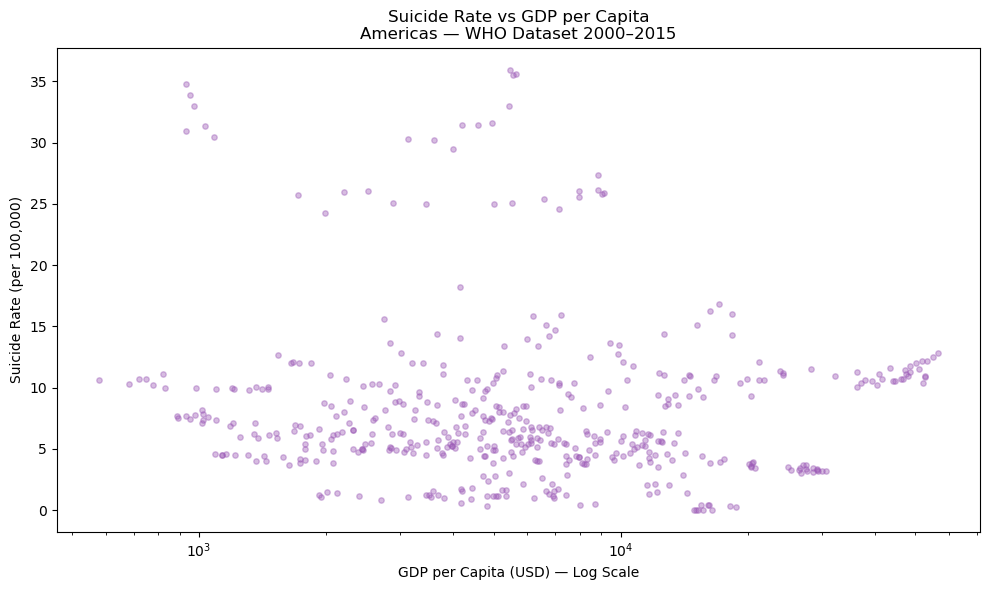

Saved: suicide_vs_gdp_Americas.png


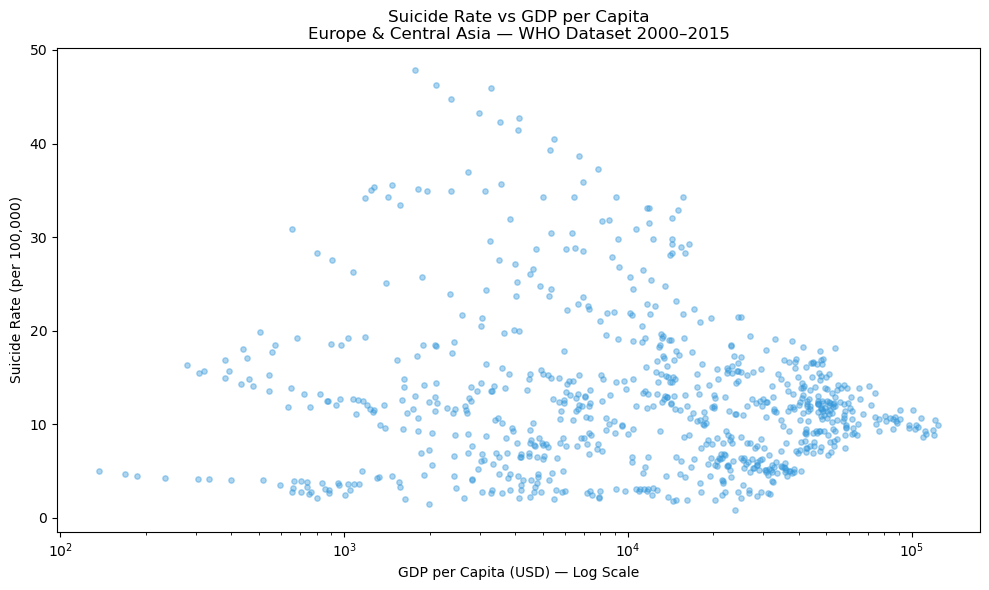

Saved: suicide_vs_gdp_Europe_and_Central_Asia.png


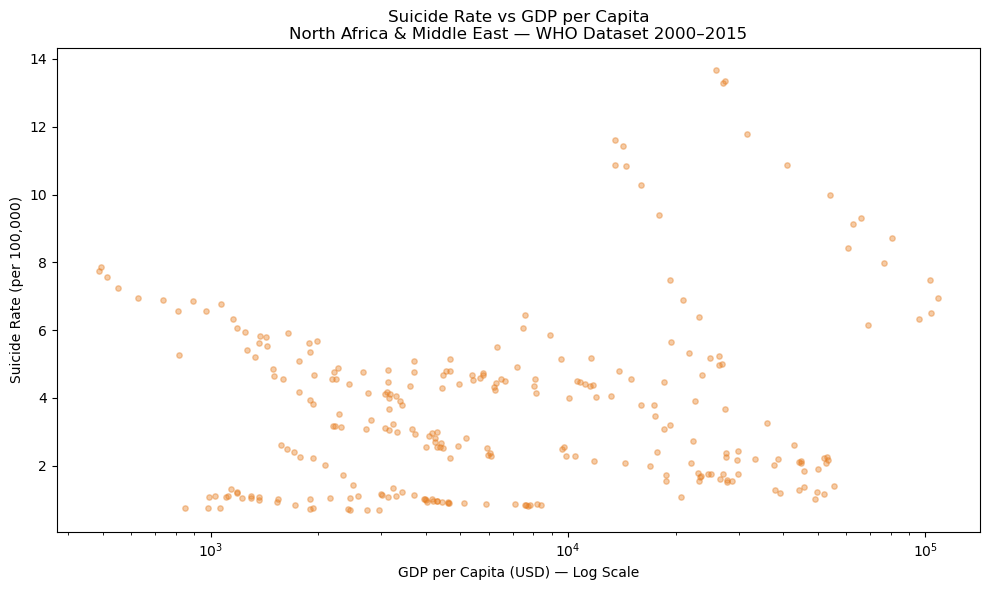

Saved: suicide_vs_gdp_North_Africa_and_Middle_East.png


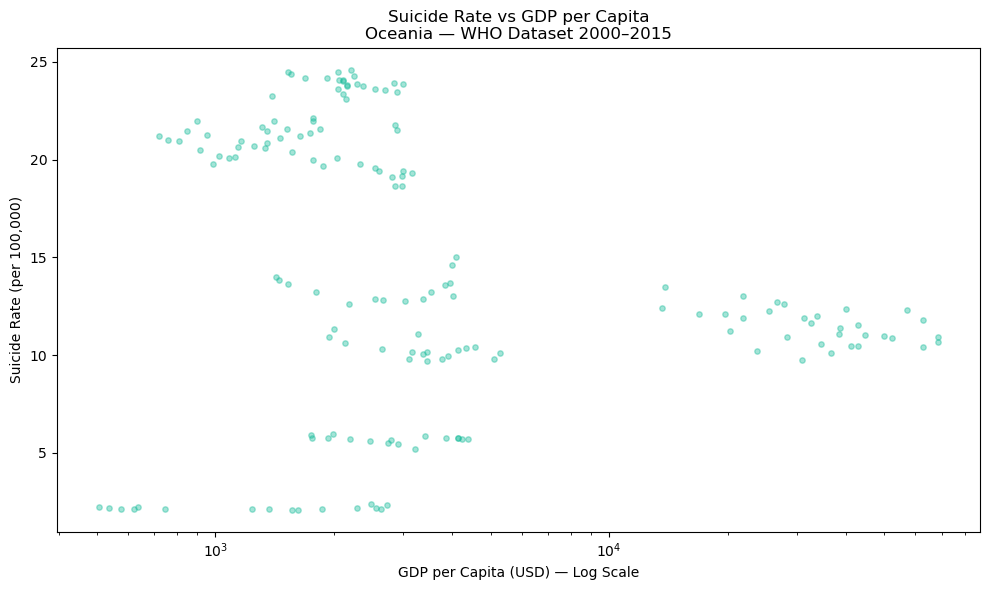

Saved: suicide_vs_gdp_Oceania.png


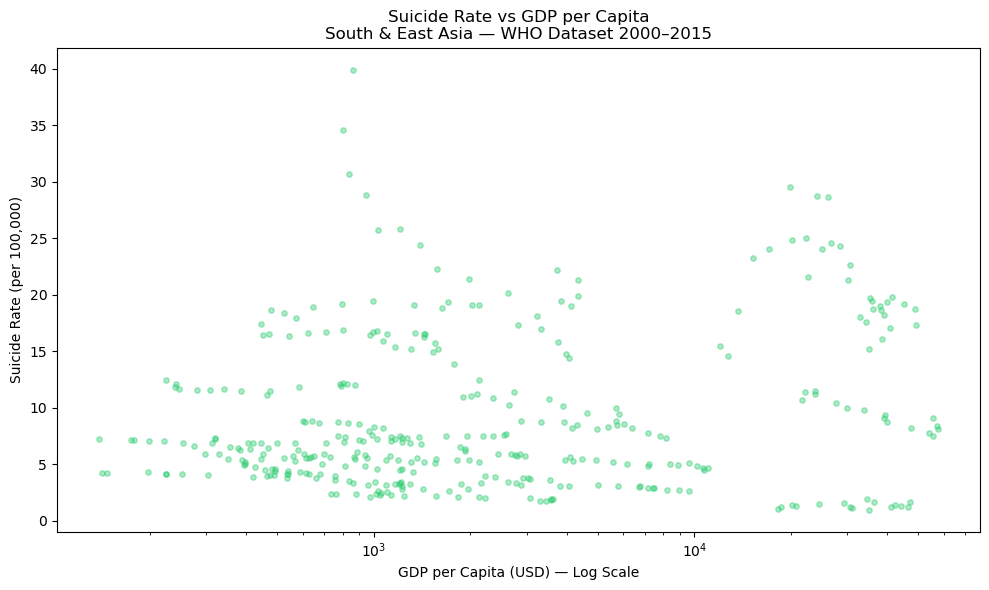

Saved: suicide_vs_gdp_South_and_East_Asia.png


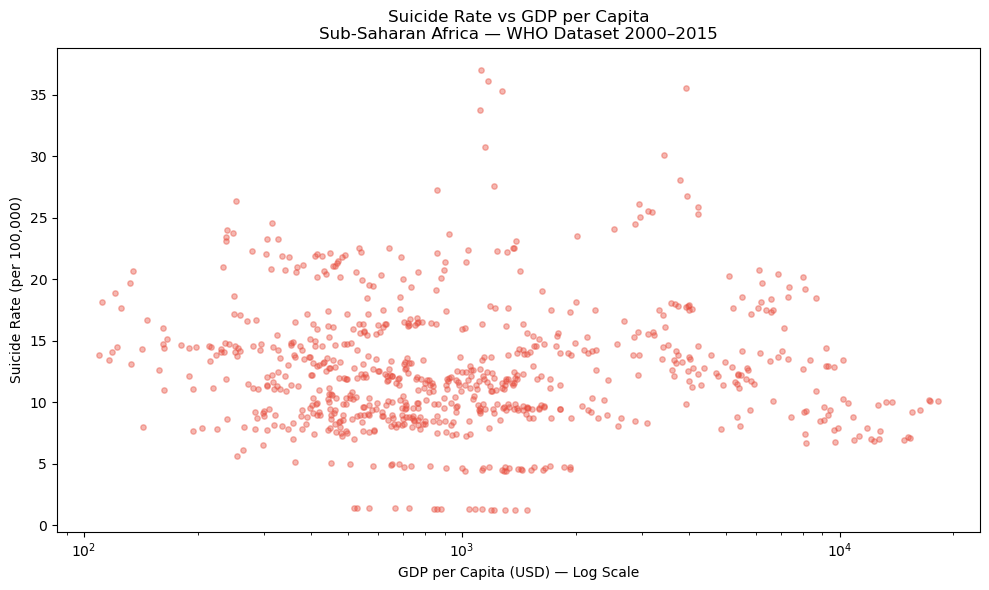

Saved: suicide_vs_gdp_Sub-Saharan_Africa.png


In [12]:
# ── EDA1 — Suicide Rate vs GDP per Capita by Region ───────────────
regions = who['Region'].dropna().unique()

for region in sorted(regions):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    group = who[who['Region'] == region]
    
    ax.scatter(
        group['GDP_per_capita'],
        group['Suicide_Rate'],
        color = region_colors[region],
        alpha = 0.4,
        s     = 15
    )
    
    ax.set_xscale('log')
    ax.set_xlabel('GDP per Capita (USD) — Log Scale')
    ax.set_ylabel('Suicide Rate (per 100,000)')
    ax.set_title(f'Suicide Rate vs GDP per Capita\n{region} — WHO Dataset 2000–2015')
    
    plt.tight_layout()
    
    filename = f"suicide_vs_gdp_{region.replace(' ', '_').replace('&', 'and')}.png"
    plt.savefig(os.path.join(CHART_DIR_EDA1, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

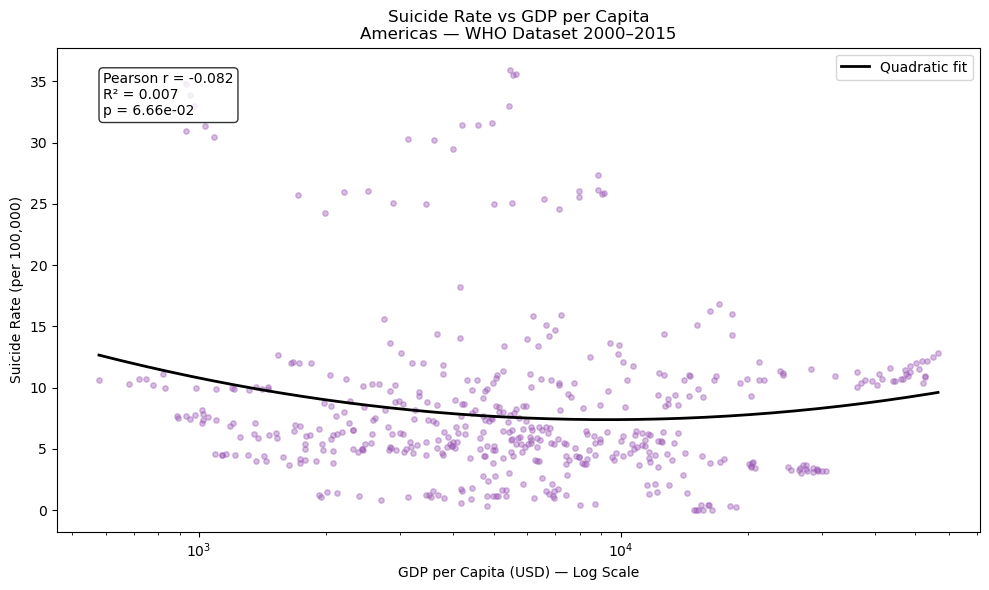

r=-0.082  R²=0.007  p=6.66e-02  Region: Americas


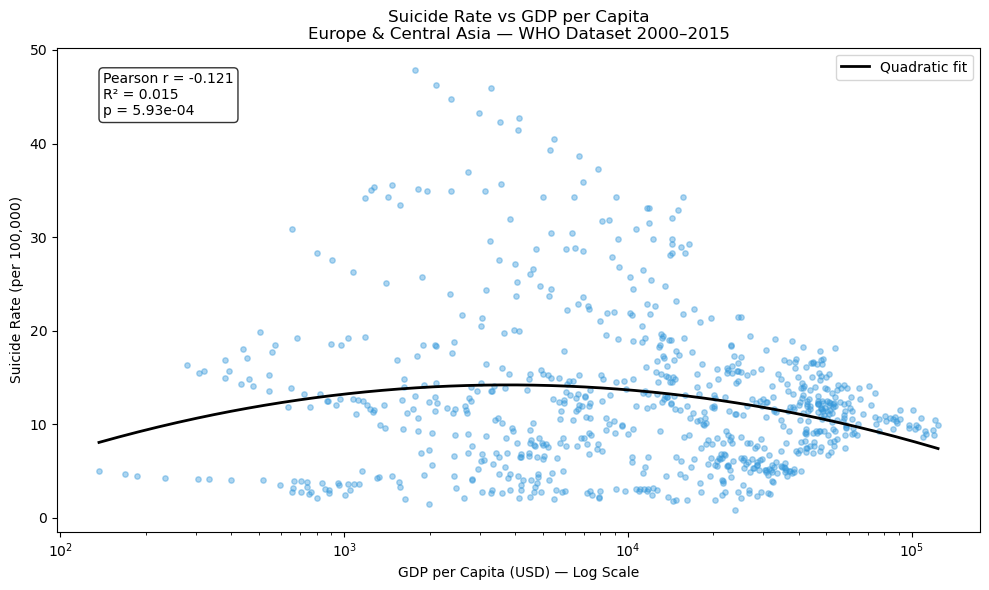

r=-0.121  R²=0.015  p=5.93e-04  Region: Europe & Central Asia


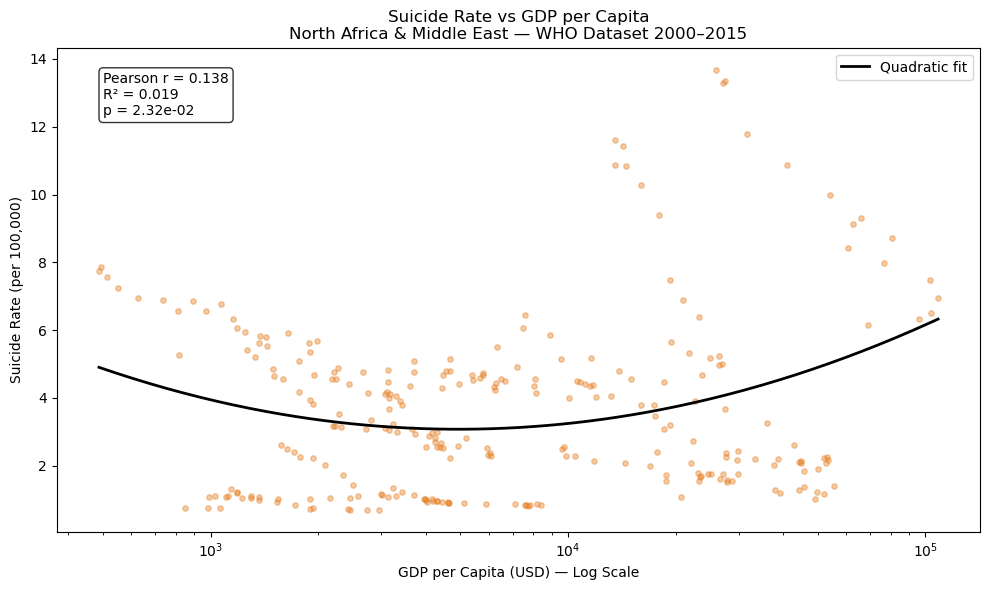

r=0.138  R²=0.019  p=2.32e-02  Region: North Africa & Middle East


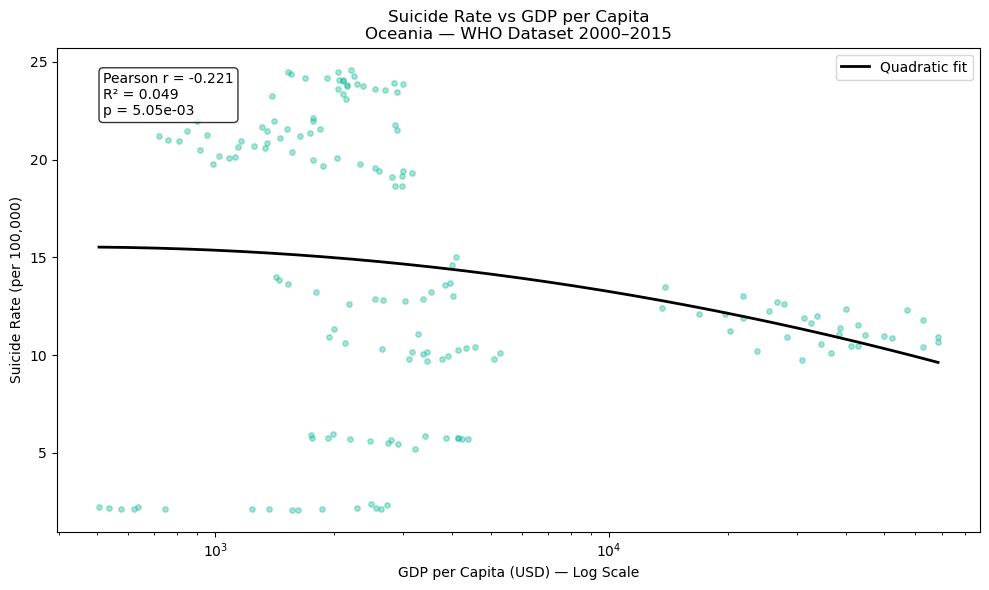

r=-0.221  R²=0.049  p=5.05e-03  Region: Oceania


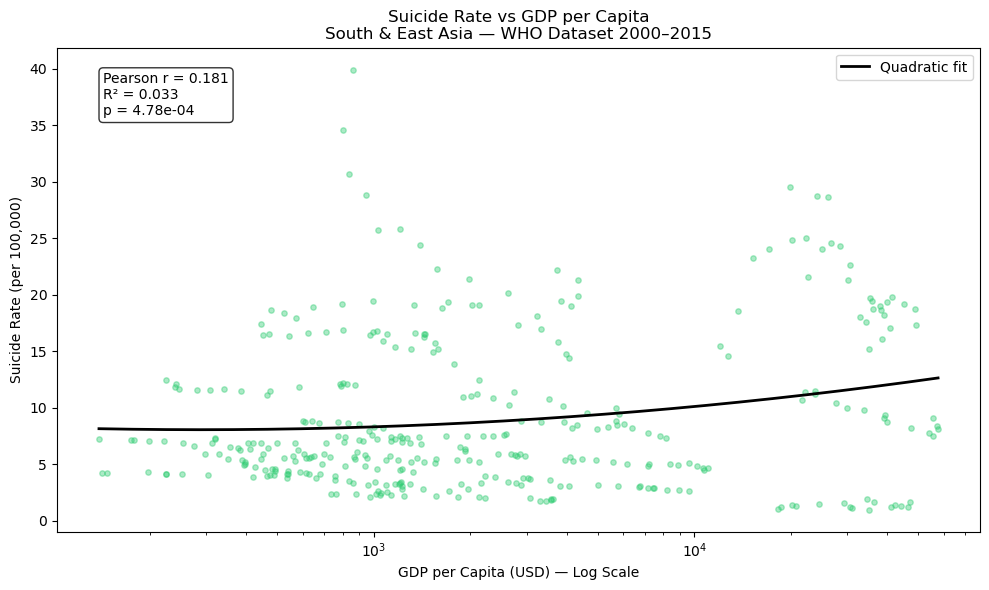

r=0.181  R²=0.033  p=4.78e-04  Region: South & East Asia


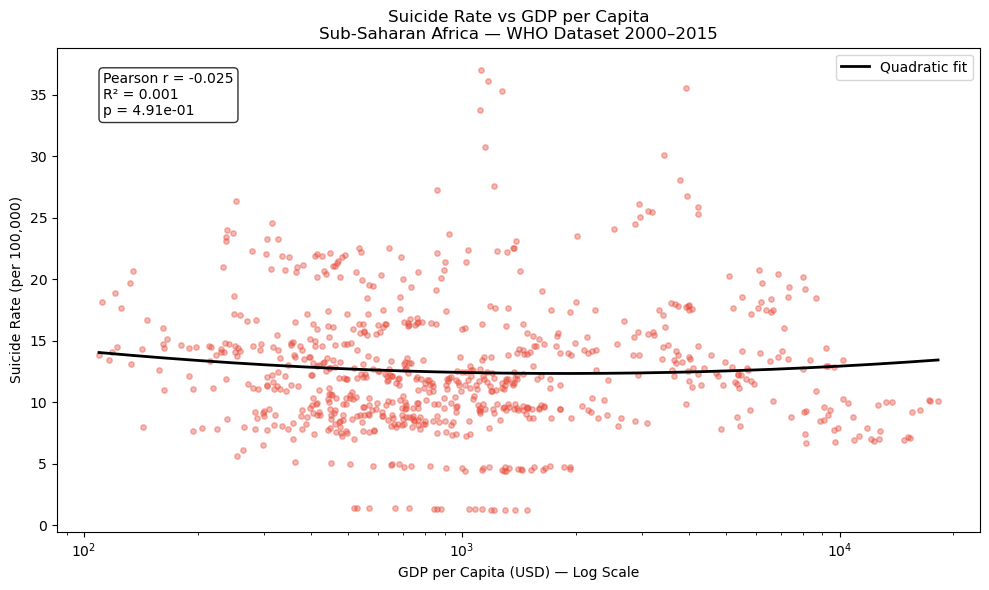

r=-0.025  R²=0.001  p=4.91e-01  Region: Sub-Saharan Africa


In [13]:
# ── EDA1 — Regional Analysis with Quadratic Fit & Pearson ──────────
regions = who['Region'].dropna().unique()

for region in sorted(regions):
    
    # ── Filter to region and drop missing values ───────────────────
    group = who[who['Region'] == region][['GDP_per_capita', 'Suicide_Rate']].dropna()
    
    log_gdp      = np.log10(group['GDP_per_capita'])
    suicide_rate = group['Suicide_Rate']
    
    # ── Pearson correlation ────────────────────────────────────────
    r, p = stats.pearsonr(log_gdp, suicide_rate)
    
    # ── Quadratic fit ──────────────────────────────────────────────
    z = np.polyfit(log_gdp, suicide_rate, 2)
    p_quad = np.poly1d(z)
    x_line = np.linspace(log_gdp.min(), log_gdp.max(), 300)
    
    # ── Plot ───────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(
        group['GDP_per_capita'],
        suicide_rate,
        color = region_colors[region],
        alpha = 0.4,
        s     = 15
    )
    
    ax.plot(
        10**x_line,
        p_quad(x_line),
        color     = 'black',
        linewidth = 2,
        label     = 'Quadratic fit'
    )
    
    ax.set_xscale('log')
    ax.set_xlabel('GDP per Capita (USD) — Log Scale')
    ax.set_ylabel('Suicide Rate (per 100,000)')
    ax.set_title(f'Suicide Rate vs GDP per Capita\n{region} — WHO Dataset 2000–2015')
    
    # ── Add stats to chart ─────────────────────────────────────────
    ax.text(
        0.05, 0.95,
        f'Pearson r = {r:.3f}\nR² = {r**2:.3f}\np = {p:.2e}',
        transform            = ax.transAxes,
        verticalalignment    = 'top',
        bbox                 = dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    ax.legend()
    plt.tight_layout()
    
    filename = f"EDA1_suicide_gdp_{region.replace(' ', '_').replace('&', 'and')}.png"
    plt.savefig(os.path.join(CHART_DIR_EDA1, filename), dpi=150, bbox_inches='tight')
    plt.show()
    print(f"r={r:.3f}  R²={r**2:.3f}  p={p:.2e}  Region: {region}")

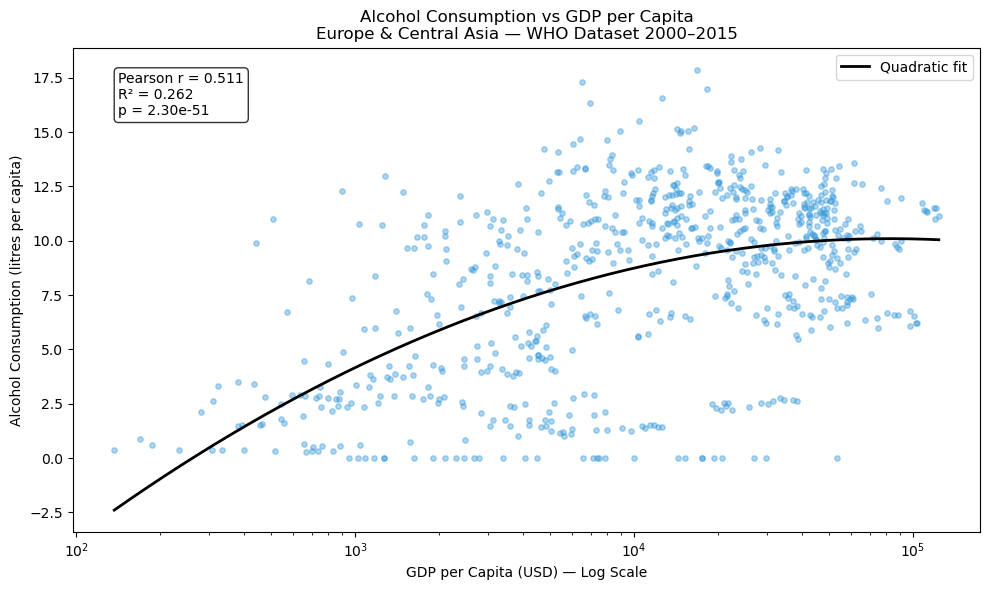

r=0.511  R²=0.262  p=2.30e-51


In [14]:
# ── Europe & Central Asia — Alcohol vs GDP per Capita ─────────────
eca = who[who['Region'] == 'Europe & Central Asia'][
    ['Country', 'Year', 'GDP_per_capita', 'Alcohol', 'Suicide_Rate']
].dropna()

log_gdp = np.log10(eca['GDP_per_capita'])
r, p    = stats.pearsonr(log_gdp, eca['Alcohol'])

z      = np.polyfit(log_gdp, eca['Alcohol'], 2)
p_quad = np.poly1d(z)
x_line = np.linspace(log_gdp.min(), log_gdp.max(), 300)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    eca['GDP_per_capita'],
    eca['Alcohol'],
    color = region_colors['Europe & Central Asia'],
    alpha = 0.4,
    s     = 15
)

ax.plot(
    10**x_line,
    p_quad(x_line),
    color     = 'black',
    linewidth = 2,
    label     = 'Quadratic fit'
)

ax.set_xscale('log')
ax.set_xlabel('GDP per Capita (USD) — Log Scale')
ax.set_ylabel('Alcohol Consumption (litres per capita)')
ax.set_title('Alcohol Consumption vs GDP per Capita\nEurope & Central Asia — WHO Dataset 2000–2015')

ax.text(
    0.05, 0.95,
    f'Pearson r = {r:.3f}\nR² = {r**2:.3f}\np = {p:.2e}',
    transform         = ax.transAxes,
    verticalalignment = 'top',
    bbox              = dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR_EDA1, 'EDA1_alcohol_gdp_Europe_and_Central_Asia.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"r={r:.3f}  R²={r**2:.3f}  p={p:.2e}")

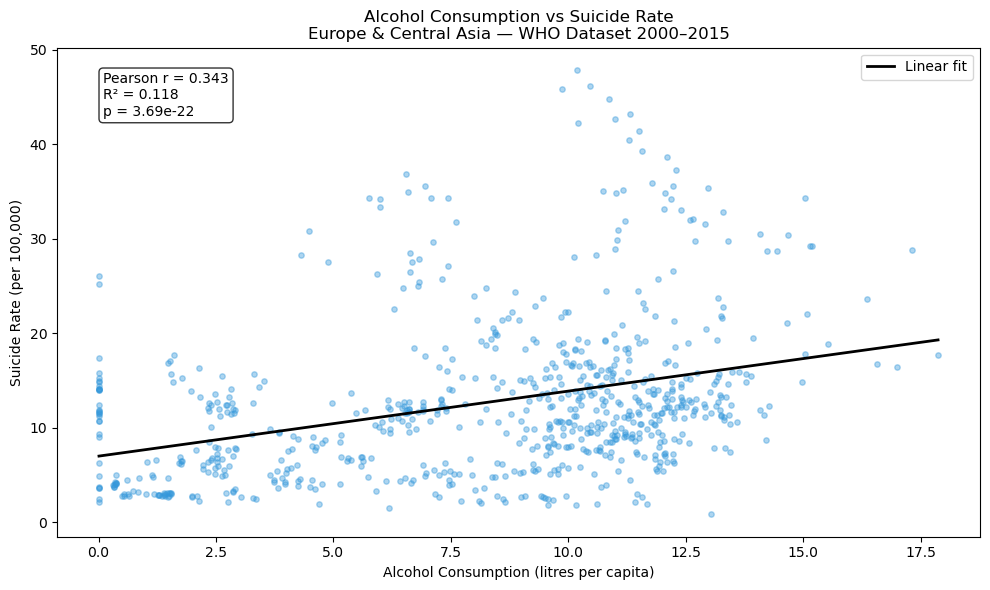

r=0.343  R²=0.118  p=3.69e-22


In [15]:
# ── Europe & Central Asia — Alcohol vs Suicide Rate ───────────────
eca = who[who['Region'] == 'Europe & Central Asia'][
    ['Country', 'Year', 'GDP_per_capita', 'Alcohol', 'Suicide_Rate']
].dropna()

r, p = stats.pearsonr(eca['Alcohol'], eca['Suicide_Rate'])

z      = np.polyfit(eca['Alcohol'], eca['Suicide_Rate'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(eca['Alcohol'].min(), eca['Alcohol'].max(), 300)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    eca['Alcohol'],
    eca['Suicide_Rate'],
    color = region_colors['Europe & Central Asia'],
    alpha = 0.4,
    s     = 15
)

ax.plot(
    x_line,
    p_line(x_line),
    color     = 'black',
    linewidth = 2,
    label     = 'Linear fit'
)

ax.set_xlabel('Alcohol Consumption (litres per capita)')
ax.set_ylabel('Suicide Rate (per 100,000)')
ax.set_title('Alcohol Consumption vs Suicide Rate\nEurope & Central Asia — WHO Dataset 2000–2015')

ax.text(
    0.05, 0.95,
    f'Pearson r = {r:.3f}\nR² = {r**2:.3f}\np = {p:.2e}',
    transform         = ax.transAxes,
    verticalalignment = 'top',
    bbox              = dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR_EDA1, 'EDA1_alcohol_vs_suicide_Europe_and_Central_Asia.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f"r={r:.3f}  R²={r**2:.3f}  p={p:.2e}")

In [16]:
print("=== WHO DATAFRAME ===")
print("Shape:", who.shape)
print("\nColumns:", who.columns.tolist())
print("\nDtypes:\n", who.dtypes)
print("\nNull counts:\n", who.isnull().sum())
print("\nSample rows:")
who.head(3)

=== WHO DATAFRAME ===
Shape: (2938, 25)

Columns: ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling', 'Country Code', 'GDP_per_capita', 'Population', 'Region', 'Suicide_Rate']

Dtypes:
 Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                   

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,HIV/AIDS,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Country Code,GDP_per_capita,Population,Region,Suicide_Rate
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,0.1,17.2,17.3,0.479,10.1,AFG,565.569730,33831764.0,South & East Asia,5.32
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,0.1,17.5,17.5,0.476,10.0,AFG,625.054942,32792523.0,South & East Asia,5.53
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,0.1,17.7,17.7,0.470,9.9,AFG,637.087099,31622704.0,South & East Asia,5.68


In [17]:
CLEAN_DIR = r"C:\Data Science\DS Projects\Health vs Wealth analysis\Clean Data"
os.makedirs(CLEAN_DIR, exist_ok=True)

who.to_csv(os.path.join(CLEAN_DIR, "who_merged_clean.csv"), index=False)
print("Saved successfully.")
print("Path:", os.path.join(CLEAN_DIR, "who_merged_clean.csv"))

Saved successfully.
Path: C:\Data Science\DS Projects\Health vs Wealth analysis\Clean Data\who_merged_clean.csv
